# The Transformer block

A decoder block repeats two transformations: causal self-attention and a position-wise feed-forward network. Residual connections preserve a running representation, while layer normalization keeps activation scales manageable.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
class MultiHeadAttention(nn.Module):
    """Causal multi-head self-attention used by the decoder block."""
    def __init__(self, channels, heads, max_time):
        super().__init__()
        if channels % heads:
            raise ValueError("channels must be divisible by heads")
        self.heads, self.head_size = heads, channels // heads
        self.query = nn.Linear(channels, channels, bias=False)
        self.key = nn.Linear(channels, channels, bias=False)
        self.value = nn.Linear(channels, channels, bias=False)
        self.output = nn.Linear(channels, channels)
        self.register_buffer("mask", torch.tril(torch.ones(max_time, max_time, dtype=torch.bool)))

    def forward(self, x):
        batch, time, channels = x.shape
        def split_heads(tensor):
            return tensor.view(batch, time, self.heads, self.head_size).transpose(1, 2)
        q, k, v = map(split_heads, (self.query(x), self.key(x), self.value(x)))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_size)
        scores = scores.masked_fill(~self.mask[:time, :time], float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        heads = weights @ v
        combined = heads.transpose(1, 2).contiguous().view(batch, time, channels)
        return self.output(combined), weights

class DecoderBlock(nn.Module):
    def __init__(self, channels, heads, max_time, expansion=4):
        super().__init__()
        self.norm_attention = nn.LayerNorm(channels)
        self.attention = MultiHeadAttention(channels, heads, max_time)
        self.norm_feed_forward = nn.LayerNorm(channels)
        self.feed_forward = nn.Sequential(
            nn.Linear(channels, expansion * channels), nn.GELU(),
            nn.Linear(expansion * channels, channels),
        )

    def forward(self, x):
        attention_output, weights = self.attention(self.norm_attention(x))
        x = x + attention_output
        x = x + self.feed_forward(self.norm_feed_forward(x))
        return x, weights

block = DecoderBlock(32, 4, 12).to(DEVICE)
x = torch.randn(3,12,32,device=DEVICE)
y, weights = block(x)
print("input:",tuple(x.shape),"output:",tuple(y.shape),"attention:",tuple(weights.shape))

input: (3, 12, 32) output: (3, 12, 32) attention: (3, 4, 12, 12)


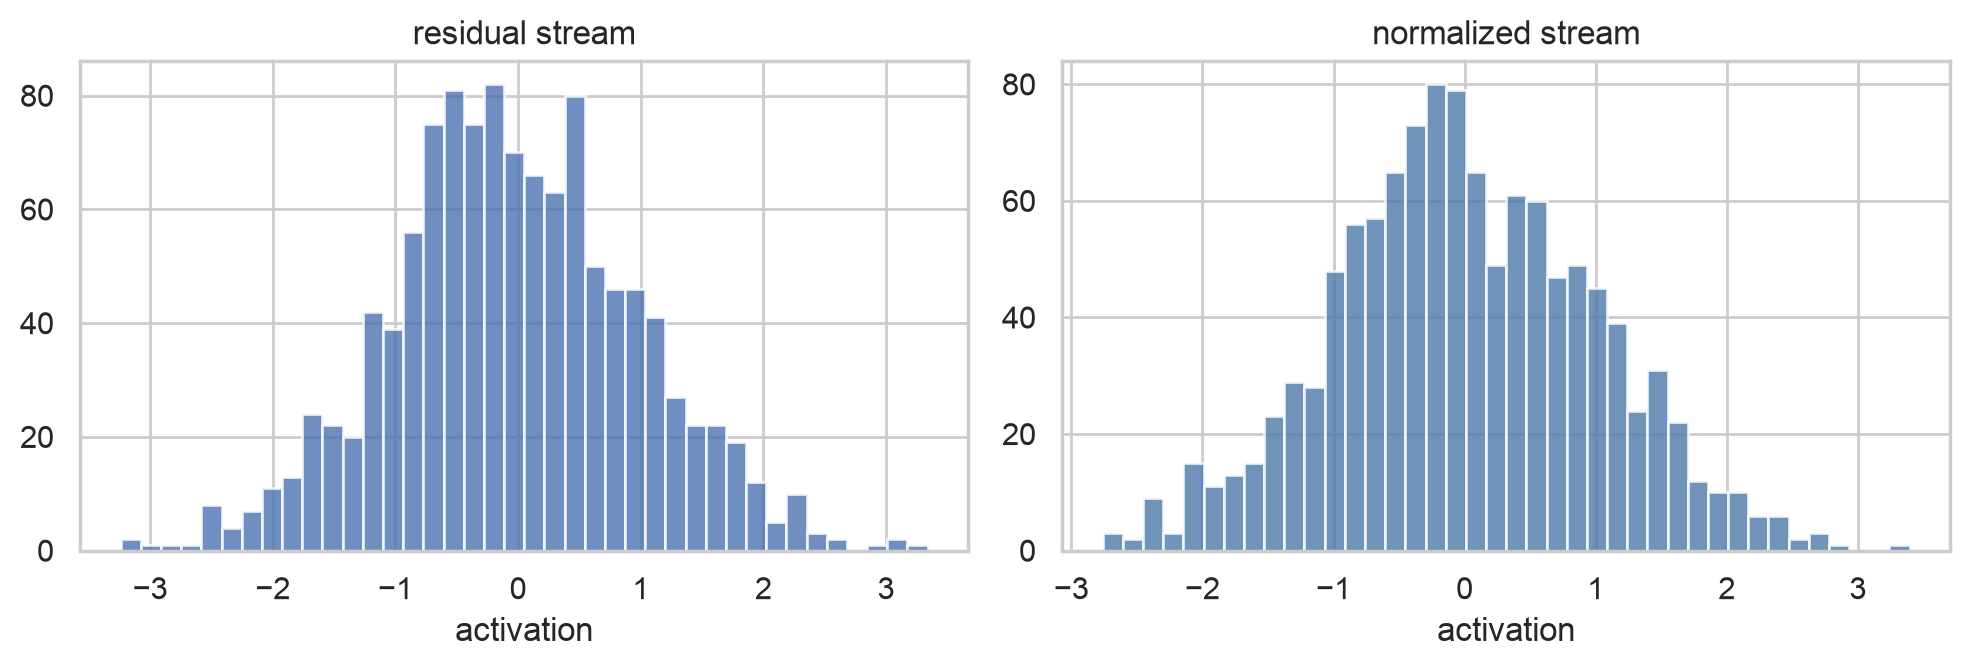

In [3]:
with torch.no_grad():
    normalized = block.norm_attention(x)
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].hist(x.detach().cpu().flatten(), bins=40, alpha=.8, label="before")
axes[0].set(title="residual stream", xlabel="activation")
axes[1].hist(normalized.detach().cpu().flatten(), bins=40, alpha=.8, color="#4c78a8", label="after LayerNorm")
axes[1].set(title="normalized stream", xlabel="activation")
plt.tight_layout(); plt.show()

## The residual stream

A block does not replace the representation with an attention output. It adds the attention update to the incoming stream, then adds a feed-forward update. This gives later blocks a stable space in which to accumulate and revise information. Layer normalization is applied before each sublayer here, the pre-normalization layout commonly used for stable deep training.

## Attention versus feed-forward computation

Attention mixes information across positions. The feed-forward network is applied independently at every position, expanding the channel dimension, applying a nonlinearity, and projecting back. A Transformer needs both: routing determines which information arrives, while the feed-forward path transforms the information once it is there.

## What the activation plot can and cannot show

Layer normalization makes the scale of each token representation more predictable, but it does not make the representations identical or remove learned information. The histogram is a diagnostic for scale, not a proof that the block is well trained.

The block is a composition, not a new kind of primitive: attention mixes information across time, the feed-forward network transforms each position independently, and residual additions let later layers refine a shared stream. Stacking blocks is what turns these local operations into a deep language model.